In [110]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from torchmetrics.regression import MeanAbsoluteError, R2Score, MeanSquaredError

In [111]:
student_mat = pd.read_csv("../datasets/student-mat.csv", sep = ";")
student_por = pd.read_csv("../datasets/student-por.csv", sep = ";")

frame = pd.concat([student_mat, student_por], ignore_index = True)
frame.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [112]:
excluded_frame = frame.drop(['school', "Pstatus", 'reason', 'guardian'], axis = 1)

In [113]:
num_cols = excluded_frame.select_dtypes(exclude = 'object').columns
obj_cols = excluded_frame.select_dtypes(include = "object").columns

In [114]:
new_frame = pd.get_dummies(excluded_frame, columns = obj_cols, drop_first = True, dtype = int)
new_frame

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,Fjob_services,Fjob_teacher,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,0,1,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,0,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,19,2,3,1,3,1,5,4,2,1,...,0,0,0,0,0,1,0,1,1,0
1040,18,3,1,1,2,0,4,3,4,1,...,1,0,0,1,0,0,1,1,1,0
1041,18,1,1,2,2,0,1,1,1,1,...,0,0,0,0,0,1,1,1,0,0
1042,17,3,1,2,1,0,2,4,5,3,...,1,0,0,0,0,0,0,1,1,0


In [115]:
# transformer = ColumnTransformer(
#     [
#         ('scale', StandardScaler(), num_cols),
#         ('encode', OneHotEncoder(drop = "first", sparse_output = False), obj_cols)
#     ]
# )

# transformed = transformer.fit_transform(frame)

In [116]:
# transformed

In [160]:
X = new_frame.drop(['G3', 'G1', 'G2'], axis = 1)
y = new_frame["G3"].to_numpy()

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [162]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [163]:
X_train_scaled[:2]

array([[-0.58511174, -0.56825442, -1.28210135,  3.31007524, -1.14639316,
        -0.37848294, -1.02038272, -1.17958973, -1.88202685, -0.55574789,
        -1.02310781, -1.07389358, -0.07091948,  1.11833531,  0.62212795,
        -0.63325091, -0.31183405, -0.79426656, -0.53534546, -0.37303373,
        -0.19962605,  0.8941862 , -0.62954036, -0.26811758, -0.35188399,
        -1.24015883, -0.50373977, -1.00359929,  0.49437974,  0.30249507,
        -1.97054331, -0.74493948],
       [ 0.23463373,  1.22566785, -0.37485167, -0.71504052,  2.41652851,
        -0.37848294,  0.0567596 , -1.17958973, -0.15035476, -0.55574789,
        -1.02310781,  0.32066496,  0.24490861, -0.8941862 ,  0.62212795,
         1.57915289, -0.31183405, -0.79426656, -0.53534546,  2.68072276,
        -0.19962605, -1.11833531,  1.5884605 , -0.26811758, -0.35188399,
         0.80634833,  1.98515198,  0.99641362,  0.49437974,  0.30249507,
         0.50747426, -0.74493948]])

In [164]:
pca = PCA(n_components = 2)
X_train_2d = pca.fit_transform(X_train_scaled)

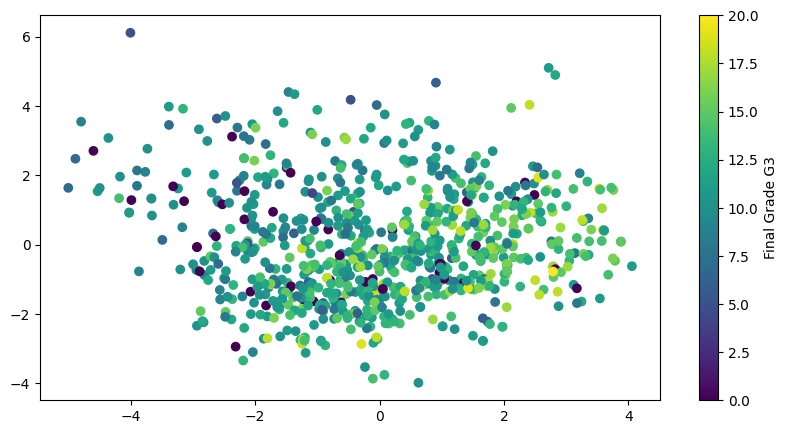

In [165]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c = y_train, cmap = "viridis")
plt.colorbar(label = "Final Grade G3")
plt.show()

In [166]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [167]:
X_train, X_test = torch.tensor(X_train_scaled, dtype = torch.float), torch.tensor(X_test_scaled, dtype = torch.float)
y_train, y_test = torch.tensor(y_train, dtype = torch.float), torch.tensor(y_test, dtype = torch.float)

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [168]:
y_train[:5]

tensor([11., 13.,  8., 11., 10.], device='mps:0')

In [169]:
X_train.shape, y_train.unique()

(torch.Size([835, 32]),
 tensor([ 0.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
         17., 18., 19., 20.], device='mps:0'))

In [244]:
class StudentPerformance(torch.nn.Module):
    def __init__(self, in_features: int = None, out_features: int = None, hidden_units: int = 16):
        super(StudentPerformance, self).__init__()
        self.in_features: int = in_features or X_train.shape[1]
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units

        self.squencelayer = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.squencelayer(x)

In [245]:
model = StudentPerformance(out_features = 1, hidden_units = 32).to(device)
model

StudentPerformance(
  (squencelayer): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [246]:
model.eval()
with torch.inference_mode():
    y_pred = model(X_test)

y_pred[:4].squeeze(), y_test[:4]

(tensor([-0.1230, -0.1727, -0.0390,  0.0702], device='mps:0'),
 tensor([11.,  8., 13., 11.], device='mps:0'))

In [247]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.05, weight_decay = 1e-4)
mae = MeanAbsoluteError().to(device)
mse = MeanSquaredError().to(device)
r2 = R2Score().to(device)

In [248]:
epochs = 10000
total_epochs = []
losses = []
test_losses = []

In [249]:
for epoch in range(epochs):
    model.train()

    y_pred = model(X_train).squeeze()
    #train_accuracy = accuracy_score(y_train.detach().cpu(), y_pred.detach().cpu())
    train_mae_value = mae(y_pred, y_train)
    train_mse_value = mse(y_pred, y_train)
    train_r2_value = r2(y_pred, y_train)

    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test).squeeze()
        #test_accuracy = accuracy_score(y_test.detach().cpu(), test_y_pred.detach().cpu())
        test_mae_value = mae(y_test_pred, y_test)
        test_mse_value = mse(y_test_pred, y_test)
        test_r2_value = r2(y_test_pred, y_test)
        
        test_loss = loss_fn(y_test_pred, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    mae.reset(); mse.reset(); r2.reset()
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")
        print(f"Train MAE: {train_mae_value:.3f} | Train MSE: {train_mse_value:.3f} | Train R2: {train_r2_value:.3f}")
        print(f"TEST MAE: {test_mae_value:.3f} | Test MSE: {test_mse_value:.3f} | Test R2: {test_r2_value:.3f}\n")
        #print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 145.96288 | Test Loss: 105.61402
Train MAE: 11.456 | Train MSE: 145.963 | Train R2: -8.888
TEST MAE: 9.671 | Test MSE: 105.614 | Test R2: -5.831

Train Loss: 0.37982 | Test Loss: 24.49993
Train MAE: 0.382 | Train MSE: 0.380 | Train R2: 0.974
TEST MAE: 3.935 | Test MSE: 24.500 | Test R2: -0.585

Train Loss: 0.28533 | Test Loss: 29.56277
Train MAE: 0.394 | Train MSE: 0.285 | Train R2: 0.981
TEST MAE: 4.310 | Test MSE: 29.563 | Test R2: -0.912

Train Loss: 0.20377 | Test Loss: 30.00156
Train MAE: 0.322 | Train MSE: 0.204 | Train R2: 0.986
TEST MAE: 4.296 | Test MSE: 30.002 | Test R2: -0.940

Train Loss: 0.16144 | Test Loss: 30.59036
Train MAE: 0.300 | Train MSE: 0.161 | Train R2: 0.989
TEST MAE: 4.377 | Test MSE: 30.590 | Test R2: -0.979

Train Loss: 0.16098 | Test Loss: 31.03244
Train MAE: 0.301 | Train MSE: 0.161 | Train R2: 0.989
TEST MAE: 4.350 | Test MSE: 31.032 | Test R2: -1.007

Train Loss: 0.13381 | Test Loss: 29.26086
Train MAE: 0.252 | Train MSE: 0.134 | Train R2: 0.